In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
listings = pd.read_csv('data/equinoxe_listings.csv').copy()
lease_history = pd.read_csv('data/equinoxe_lease_history.csv').copy()
concessions = pd.read_csv('data/equinoxe_concessions.csv').copy()
asking_history = pd.read_csv('data/equinoxe_asking_history.csv').copy()

,sUnitType,lease_year,leases,units,median_contractual_rent,median_effective_rent,contractual_yoy_pct,effective_yoy_pct
0,0_1,2022,10,10,1155.0,1080.46,NaN,NaN
1,0_1,2023,44,44,2260.0,2210.00,95.67,104.54
2,0_1,2024,50,49,2325.0,2230.05,2.88,0.91
3,0_1,2025,48,48,2520.0,2276.46,8.39,2.08
4,1_1,2017,2,2,865.0,852.90,NaN,NaN
...,...,...,...,...,...,...,...,...
66,3_3,2020,1,1,3060.0,2934.62,3.20,-1.02
67,3_3,2021,1,1,3235.0,3235.00,5.72,10.24
68,3_3,2022,1,1,3475.0,3290.05,7.42,1.70
69,3_3,2023,1,1,3695.0,3458.43,6.33,5.12


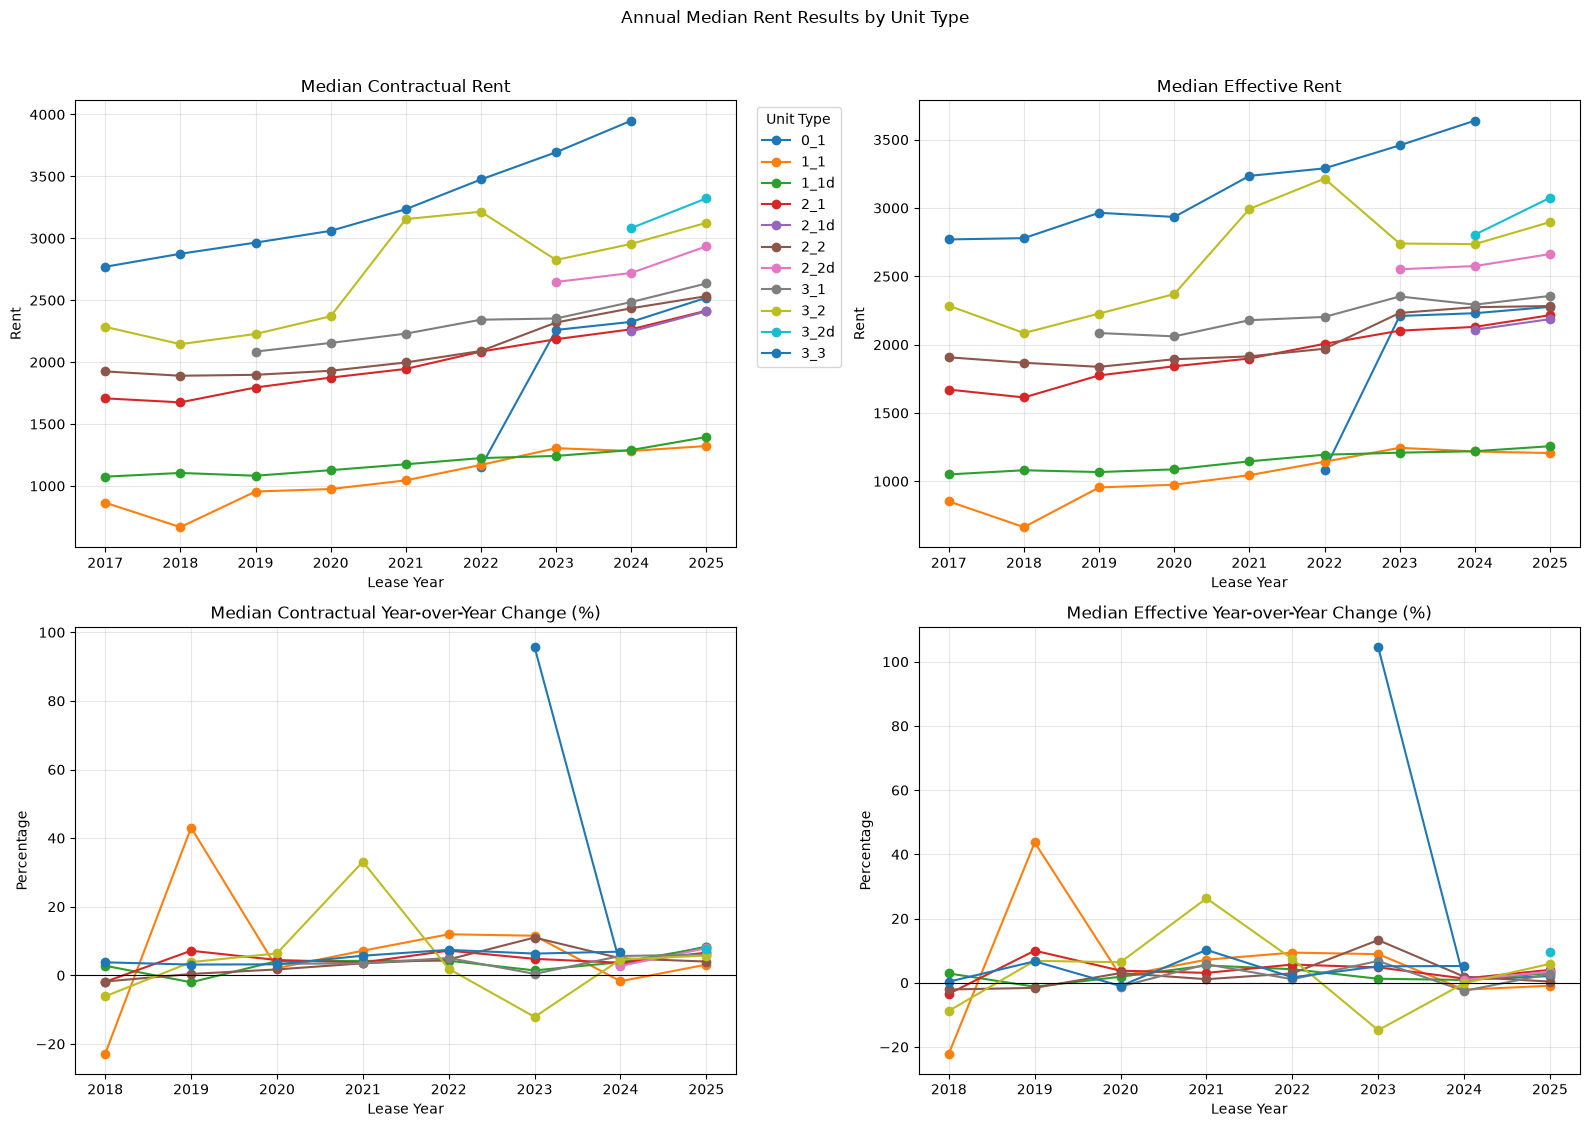

In [13]:
# Annual median rent summary by unit type

from IPython.display import display

lease_history['sLeaseFrom'] = pd.to_datetime(lease_history['sLeaseFrom'])
lease_history['sUnitType'] = lease_history['sUnitType'].astype(str).str.strip()
lease_history['lease_year'] = lease_history['sLeaseFrom'].dt.year

# Aggregate across all properties within each unit type.
annual_rent_table = (
    lease_history
    .groupby(['sUnitType', 'lease_year'])
    .agg(
        leases=('hUnit', 'size'),
        units=('hUnit', 'nunique'),
        median_contractual_rent=('sRent', 'median'),
        median_effective_rent=('sRentEffective', 'median'),
    )
    .reset_index()
    .sort_values(['sUnitType', 'lease_year'])
)

# Compare each year with the previous year within the same unit type.
annual_rent_table['contractual_yoy_pct'] = (
    annual_rent_table
    .groupby('sUnitType')['median_contractual_rent']
    .pct_change()
    .mul(100)
)
annual_rent_table['effective_yoy_pct'] = (
    annual_rent_table
    .groupby('sUnitType')['median_effective_rent']
    .pct_change()
    .mul(100)
)

rounded_table = annual_rent_table.round({
    'median_contractual_rent': 2,
    'median_effective_rent': 2,
    'contractual_yoy_pct': 2,
    'effective_yoy_pct': 2,
})
display(rounded_table)

# Plot median rent levels and year-over-year changes for each unit type.
plot_columns = {
    'median_contractual_rent': 'Median Contractual Rent',
    'median_effective_rent': 'Median Effective Rent',
    'contractual_yoy_pct': 'Median Contractual Year-over-Year Change (%)',
    'effective_yoy_pct': 'Median Effective Year-over-Year Change (%)',
}

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=False)
for column, title, axis in zip(plot_columns, plot_columns.values(), axes.flat):
    plot_data = annual_rent_table.pivot(
        index='lease_year',
        columns='sUnitType',
        values=column,
    )
    for unit_type in plot_data.columns:
        axis.plot(
            plot_data.index,
            plot_data[unit_type],
            marker='o',
            label=unit_type,
        )
    axis.set_title(title)
    axis.set_xlabel('Lease Year')
    axis.grid(alpha=0.3)
    if 'pct' in column:
        axis.axhline(0, color='black', linewidth=0.8)
        axis.set_ylabel('Percentage')
    else:
        axis.set_ylabel('Rent')

axes[0, 0].legend(title='Unit Type', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.suptitle('Annual Median Rent Results by Unit Type', y=1.02)
fig.tight_layout()
plt.show()

,sPropCode,lease_year,leases,units,median_contractual_rent,median_effective_rent,contractual_yoy_pct,effective_yoy_pct
0,carlyle,2023,155,152,2225.0,2145.00,NaN,NaN
1,carlyle,2024,195,182,2350.0,2183.03,5.62,1.77
2,carlyle,2025,185,183,2475.0,2214.00,5.32,1.42
3,dj1,2019,48,47,1855.0,1796.52,NaN,NaN
4,dj1,2020,57,57,1935.0,1935.00,4.31,7.71
5,dj1,2021,57,57,2055.0,1980.00,6.20,2.33
6,dj1,2022,55,55,2115.0,2069.90,2.92,4.54
7,dj1,2023,57,57,2155.0,2072.27,1.89,0.11
8,dj1,2024,58,57,2255.0,2080.70,4.64,0.41
9,dj1,2025,59,58,2405.0,2131.81,6.65,2.46


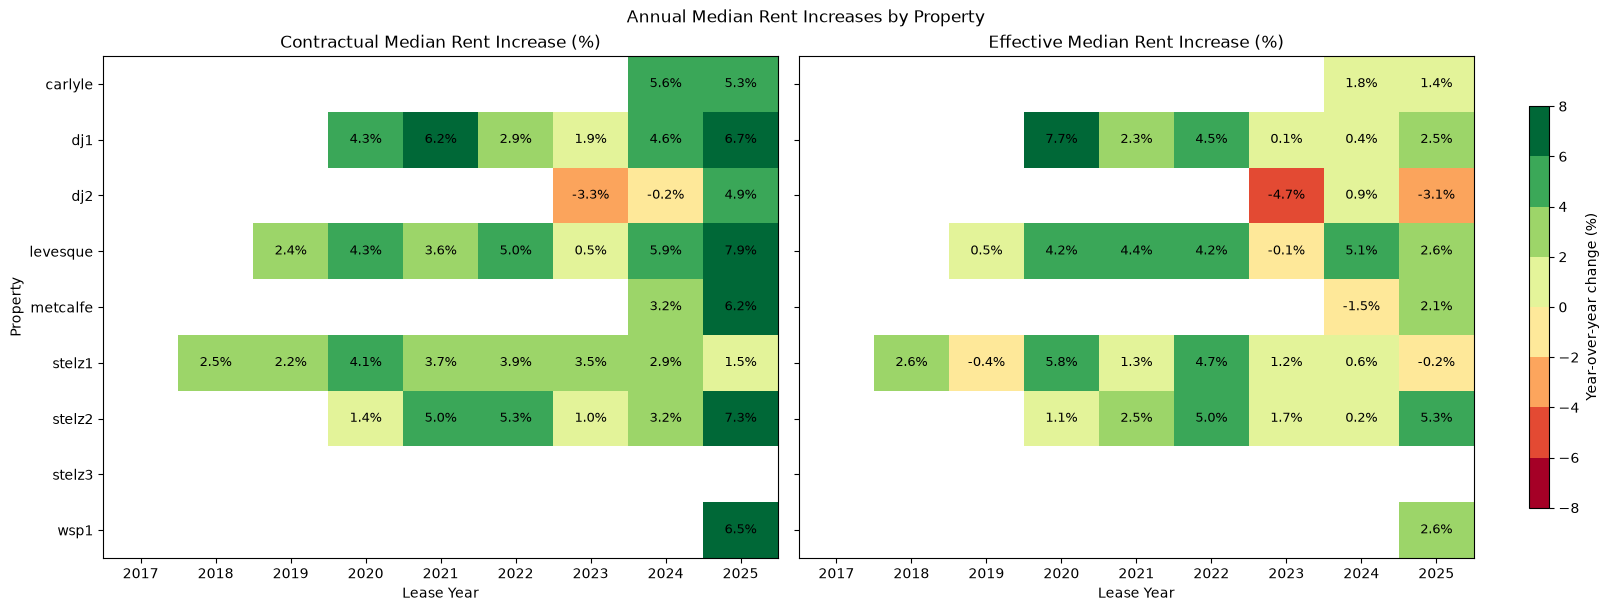

In [14]:
# Annual median rent increase by sPropCode

from IPython.display import display
from matplotlib.colors import BoundaryNorm

lease_history['sPropCode'] = lease_history['sPropCode'].astype(str).str.strip()
lease_history['sLeaseFrom'] = pd.to_datetime(lease_history['sLeaseFrom'])
lease_history['lease_year'] = lease_history['sLeaseFrom'].dt.year

median_rent_by_property = (
    lease_history
    .groupby(['sPropCode', 'lease_year'])
    .agg(
        leases=('hUnit', 'size'),
        units=('hUnit', 'nunique'),
        median_contractual_rent=('sRent', 'median'),
        median_effective_rent=('sRentEffective', 'median'),
    )
    .reset_index()
    .sort_values(['sPropCode', 'lease_year'])
)

# Compare each year with the previous year within the same property.
median_increase_by_property = median_rent_by_property.copy()
median_increase_by_property['contractual_yoy_pct'] = (
    median_increase_by_property
    .groupby('sPropCode')['median_contractual_rent']
    .pct_change()
    .mul(100)
)
median_increase_by_property['effective_yoy_pct'] = (
    median_increase_by_property
    .groupby('sPropCode')['median_effective_rent']
    .pct_change()
    .mul(100)
)

# Return a table with the median rent increase for each property.
display(
    median_increase_by_property.round({
        'median_contractual_rent': 2,
        'median_effective_rent': 2,
        'contractual_yoy_pct': 2,
        'effective_yoy_pct': 2,
    })
)

# Heatmaps make the direction and size of each property's annual change easy to compare.
heatmap_columns = {
    'contractual_yoy_pct': 'Contractual Median Rent Increase (%)',
    'effective_yoy_pct': 'Effective Median Rent Increase (%)',
}
heatmaps = {
    column: median_increase_by_property.pivot(
        index='sPropCode',
        columns='lease_year',
        values=column,
    )
    for column in heatmap_columns
}

all_changes = pd.concat([heatmap.stack() for heatmap in heatmaps.values()]).dropna()
observed_limit = float(all_changes.abs().max())
scale_limit = max(8.0, np.ceil(observed_limit / 2) * 2)
color_boundaries = np.arange(-scale_limit, scale_limit + 2, 2)
color_map = plt.get_cmap('RdYlGn', len(color_boundaries) - 1)
color_norm = BoundaryNorm(color_boundaries, color_map.N, clip=True)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    sharey=True,
    constrained_layout=True,
)
for axis, (column, title) in zip(axes, heatmap_columns.items()):
    heatmap = heatmaps[column]
    image = axis.imshow(
        heatmap,
        aspect='auto',
        cmap=color_map,
        norm=color_norm,
    )
    axis.set_title(title)
    axis.set_xlabel('Lease Year')
    axis.set_xticks(range(len(heatmap.columns)))
    axis.set_xticklabels(heatmap.columns)
    axis.set_yticks(range(len(heatmap.index)))
    axis.set_yticklabels(heatmap.index)

    for row_index in range(heatmap.shape[0]):
        for column_index in range(heatmap.shape[1]):
            value = heatmap.iloc[row_index, column_index]
            if pd.notna(value):
                axis.text(
                    column_index,
                    row_index,
                    f'{value:.1f}%',
                    ha='center',
                    va='center',
                    fontsize=9,
                )

axes[0].set_ylabel('Property')
fig.colorbar(
    image,
    ax=axes,
    ticks=color_boundaries,
    label='Year-over-year change (%)',
    shrink=0.8,
    pad=0.04,
)
fig.suptitle('Annual Median Rent Increases by Property')
plt.show()

In [15]:
# Difference between contractual rent and effective rent per building
prop_rent = lease_history.groupby('sPropCode')[['sRent', 'sRentEffective']].sum()
pct_diff = (prop_rent['sRent'] - prop_rent['sRentEffective']) / prop_rent['sRent'] * 100
pct_diff

sPropCode
carlyle     7.094196
dj1         4.007418
dj2         4.910493
levesque    3.700786
metcalfe    7.297358
stelz1      2.957511
stelz2      4.042587
stelz3      8.103773
wsp1        8.309368
dtype: float64

# Findings

All newer constructions show much higher concessions versus older constructions. 

In [16]:
# Sort by property, unit code, and term sequence
df_sorted = lease_history.sort_values(by=['sPropCode', 'sUnitCode', 'sTermSeq'])

# Calculate the percentage rent increase per unit
df_sorted['rent_increase'] = df_sorted.groupby(['sPropCode', 'sUnitCode'])['sRent'].pct_change() * 100

# Drop first leases (NaN rent increases)
df_increases = df_sorted.dropna(subset=['rent_increase'])

# Group by building and renewal status, calculate mean rent increase
res = df_increases.groupby(['sBuilding', 'sRenewal'])['rent_increase'].mean().unstack()

# Calculate the difference between renewals and turnovers
res['diff_renewal_vs_turnover'] = res[1] - res[0]
res


sRenewal,0,1,diff_renewal_vs_turnover
sBuilding,,,
Daniel-Johnson,5.183487,4.247655,-0.935832
Le Carlyle,6.949063,5.065475,-1.883588
Levesque,3.646203,4.329933,0.683730
Saint-Elzear,3.783362,4.268563,0.485202
The Met,7.467893,4.630683,-2.837210
Westpark,9.591098,6.215854,-3.375244


### 1. The "Cap" vs. "Calculated" Distribution Analysis
Plot the distribution (boxplot) of Year-over-Year (YoY) rent increases for renewals only, separating "The Met" (Ontario) from the Quebec buildings.

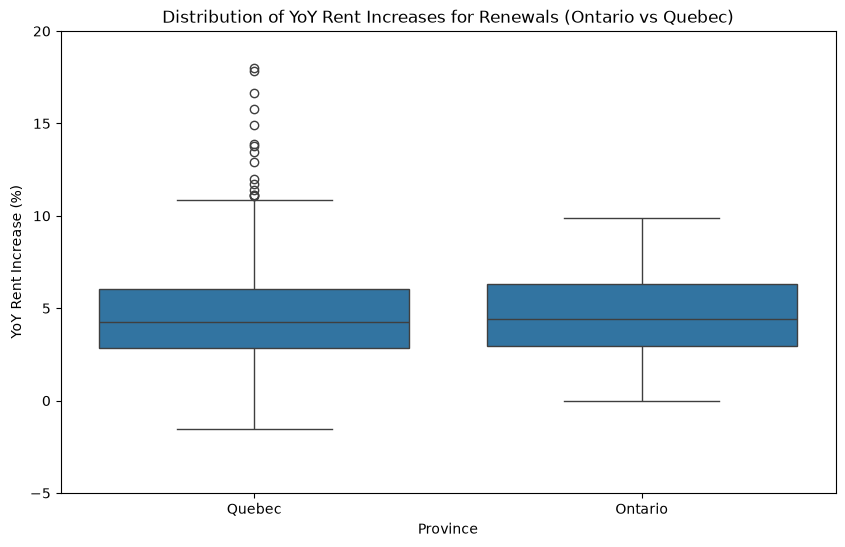

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
# Calculate YoY percent if not already done
lease_history = pd.read_csv("data/equinoxe_lease_history.csv").copy()
lease_history["sRent"] = pd.to_numeric(lease_history["sRent"], errors="coerce")
lease_history = lease_history.sort_values(by=["sPropCode", "sUnitCode", "sTermSeq"])
lease_history["prev_rent"] = lease_history.groupby(["sPropCode", "sUnitCode"])["sRent"].shift(1)
lease_history["contractual_yoy_pct"] = (lease_history["sRent"] / lease_history["prev_rent"] - 1) * 100

df_analysis = lease_history.dropna(subset=["contractual_yoy_pct"]).copy()
df_analysis["sRenewal"] = pd.to_numeric(df_analysis["sRenewal"], errors="coerce")
df_analysis["Province"] = df_analysis["sState"]

renewals = df_analysis[df_analysis["sRenewal"] == 1].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(x="Province", y="contractual_yoy_pct", data=renewals)
plt.title("Distribution of YoY Rent Increases for Renewals (Ontario vs Quebec)")
plt.ylabel("YoY Rent Increase (%)")
plt.ylim(-5, 20)
plt.show()

### 2. New Leases vs. Renewals (The Mark-to-Market Gap)
Segment the `contractual_yoy_pct` into two groups: "Lease Renewals" and "New Tenant Leases", and compare the gap between these two groups across the provinces.

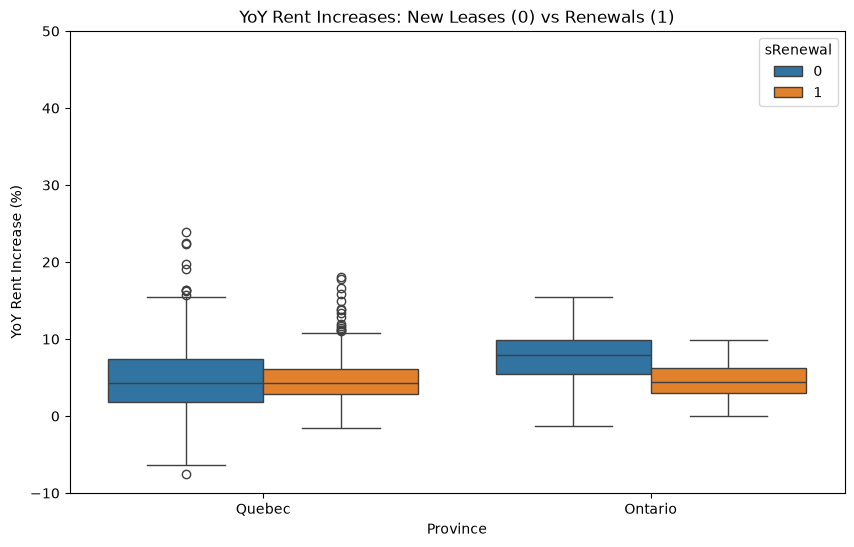

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Province", y="contractual_yoy_pct", hue="sRenewal", data=df_analysis)
plt.title("YoY Rent Increases: New Leases (0) vs Renewals (1)")
plt.ylabel("YoY Rent Increase (%)")
plt.ylim(-10, 50)
plt.show()

### 3. Summary of Findings

Based on the visualizations above, we can draw the following conclusions regarding rent increase patterns in Quebec vs. Ontario (The Met):

**1. "The Met" Appears to be Exempt from Ontario Rent Control:**
In Ontario, buildings occupied prior to November 15, 2018, are strictly capped by the provincial rent increase guideline (typically around 1.2% - 2.5%). However, the distribution of renewal increases for Ontario shows a median of roughly 4-5%, with many increases stretching up to 10%. This lack of a hard cap strongly suggests that "The Met" is a newer building exempt from the standard Ontario rent control laws, allowing the landlord to set renewal increases based on market conditions rather than provincial limits. 

**2. Quebec's "Calculated" Increases:**
The Quebec distribution behaves as expected for a province without a hard cap but with a cost-based calculation mechanism. The median renewal increase is also around 4-5%, but the data has a heavy tail of outliers extending up to 18%. This reflects the flexibility landlords have to pass on significant building costs (like major renovations or tax spikes) if justified, or instances where tenants simply accept higher proposed increases.

**3. The Mark-to-Market Gap on Turnover:**
The second graph highlights a clear difference in pricing strategy during tenant turnover (New Leases) versus retention (Renewals):
*   **Ontario:** There is a distinct "Mark-to-Market" gap. New leases command significantly higher rent increases (median ~8%) compared to renewals (median ~4%). Even without strict rent control, the landlord appears to apply moderate increases to retain existing tenants, while capitalizing on turnovers to aggressively hike rents to the current market rate.
*   **Quebec:** The gap between new leases and renewals is less pronounced. In fact, the median increase for new leases is very close to (or even slightly lower than) renewals, though the variance is wider (including some rent decreases). This could be influenced by Quebec's "Clause G" regulations, which require landlords to disclose the lowest rent paid in the previous 12 months, giving new tenants leverage to refuse exorbitant spikes on turnover.
